In [1]:
#Imports & Load

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#load dataset
df = pd.read_csv('../data/HR_Attrition.csv')


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
#Data Cleaning
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
print(df.isnull().sum().sum())        # total nulls


0


In [8]:
print(df.duplicated().sum())          # duplicate rows


0


In [9]:
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [10]:
# Drop constant/useless columns (same value everywhere, no analytical value)
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'], inplace=True, errors='ignore')

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


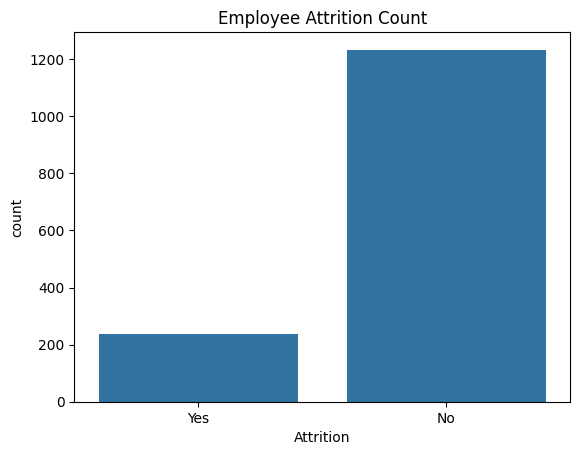

In [11]:
#Univariate: Overall Attrition Rate

attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_rate)

sns.countplot(data=df, x='Attrition')
plt.title('Employee Attrition Count')
plt.savefig('../outputs/charts/attrition_count.png')
plt.show()

In [12]:
#Quick Insight: Baseline attrition rate ~16% hai — ye industry average (~10-15%) se thoda zyada hai,
#so ye number tumhare aage ke findings ke liye reference point rahega.

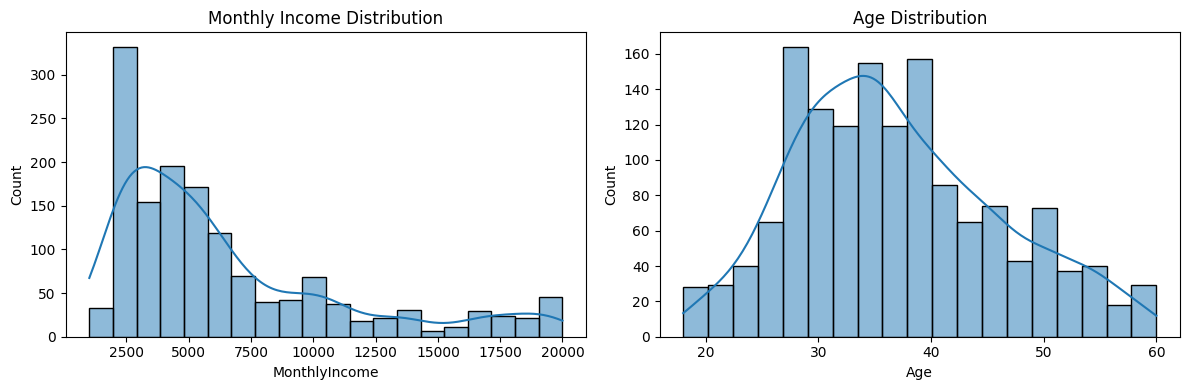

In [13]:
#Income & Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[0])
axes[0].set_title('Monthly Income Distribution')
sns.histplot(df['Age'], kde=True, ax=axes[1])
axes[1].set_title('Age Distribution')
plt.tight_layout()
plt.savefig('../outputs/charts/income_age_dist.png')
plt.show()

In [ ]:
# Insight: Income right-skewed hone ki wajah se, jab hum baad mein t-test karenge (Attrition=Yes vs No income compare),
# median bhi check karna better rahega mean ke saath — skewed data mein mean thoda misleading ho sakta hai.

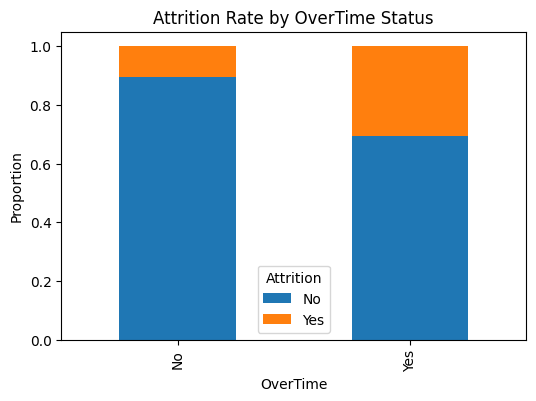

In [15]:
#OverTime vs Attrition
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index').plot(kind='bar', stacked=True, figsize=(6,4))
plt.title('Attrition Rate by OverTime Status')
plt.ylabel('Proportion')
plt.savefig('../outputs/charts/overtime_attrition.png')
plt.show()

In [16]:
#Finding: OverTime=No wale employees mein attrition ~10% hai, jabki OverTime=Yes wale employees mein attrition ~30% hai 
# (visually orange portion teeno gunaa bada hai).
#So What: OverTime karne wale employees ka attrition risk teen guna zyada hai non-OT employees ke comparison mein.

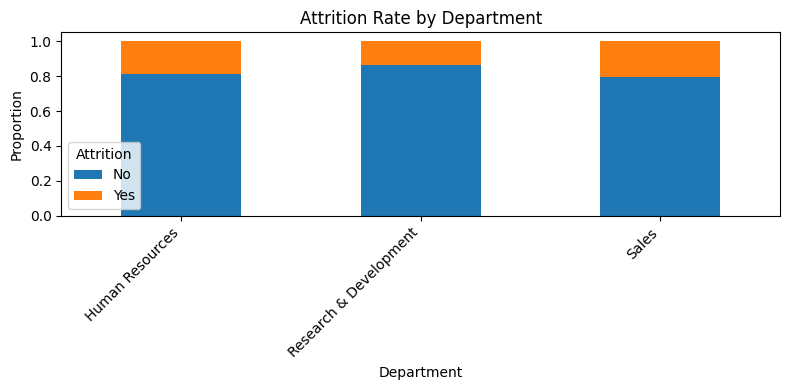

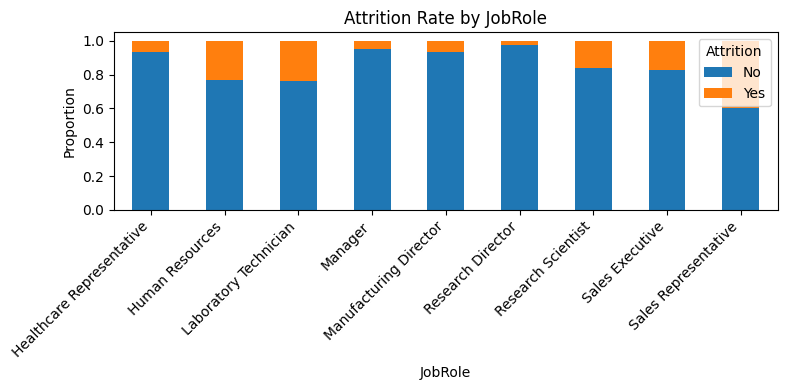

In [17]:
#Department & JobRole vs Attrition
for col in ['Department', 'JobRole']:
    pd.crosstab(df[col], df['Attrition'], normalize='index').plot(kind='bar', stacked=True, figsize=(8,4))
    plt.title(f'Attrition Rate by {col}')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'../outputs/charts/{col}_attrition.png')
    plt.show()

In [ ]:
#Insights
#Department:

# Department           Attrition (visual estimate)
# Sales                        20%(highest)
# HR                           19%
# R&D                          14% (lowest)

In [ ]:
#Finding: Sales department ka attrition rate sabse zyada hai teeno departments mein.
#So What: Sales role structurally high-pressure/high-turnover hai (targets, travel, incentive-based stress).

#JobRole:
#Sales Representative aur Laboratory Technician mein orange (Yes) portion sabse bada dikh raha hai — inka attrition sabse high hai;
#Manager, Research Director, Manufacturing Director mein attrition bahut kam hai (senior/stable roles).

#So What: Attrition entry-level/individual-contributor roles mein zyada concentrated hai, senior/leadership roles mein retention strong hai
#  — ye normal career-stage pattern hai but HR ke liye actionable hai (junior role engagement pe focus).

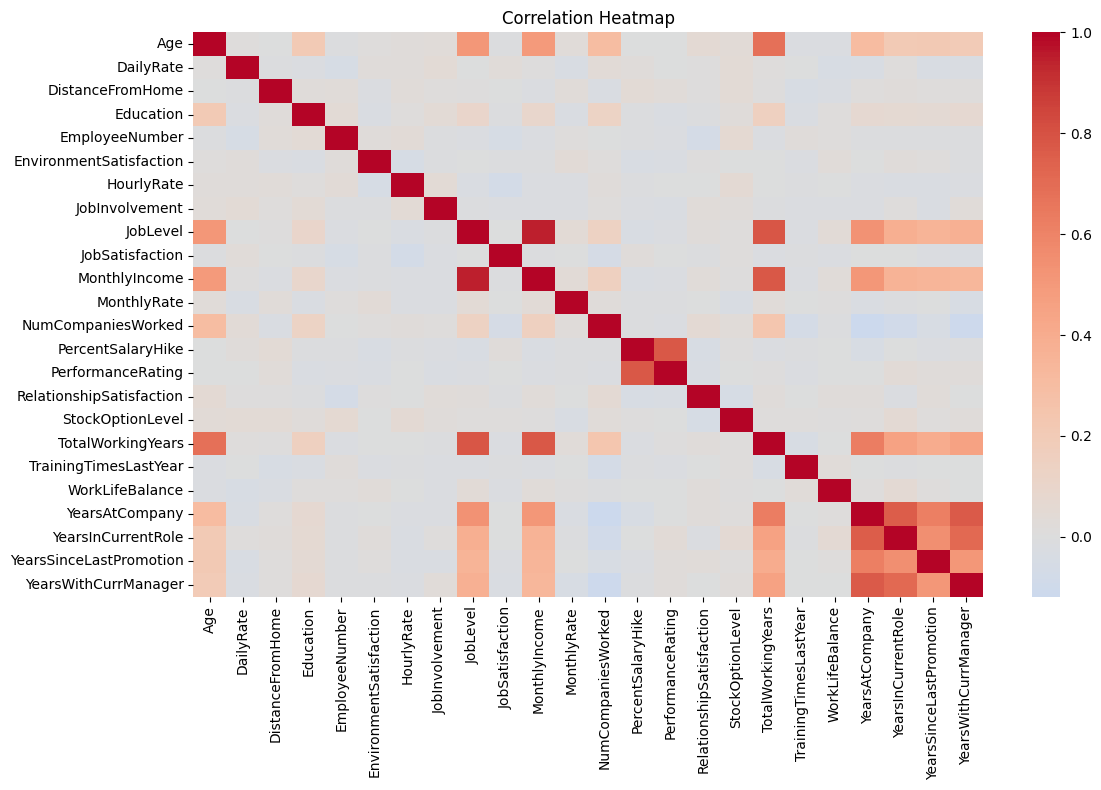

In [21]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/charts/correlation_heatmap.png')
plt.show()

In [ ]:
# Correlation Heatmap Insight
# Sabse strong correlations (dark red cells):

# MonthlyIncome ↔ JobLevel, TotalWorkingYears, Age — expected, senior/experienced employees zyada kamate hain
# YearsAtCompany ↔ YearsInCurrentRole, YearsWithCurrManager, YearsSinceLastPromotion — bottom-right cluster —
# jo employees zyada time se company mein hain, unke roles/managers bhi stable rehte hain

In [ ]:
# Hypothesis Tests 

In [22]:
#Hypothesis Test 1: OverTime vs Attrition
contingency = pd.crosstab(df['OverTime'], df['Attrition'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi2: {chi2:.2f}, p-value: {p:.4f}")
if p < 0.05:
    print("Result: Statistically significant — OverTime aur Attrition related hain")
else:
    print("Result: Not significant")

Chi2: 87.56, p-value: 0.0000
Result: Statistically significant — OverTime aur Attrition related hain


In [ ]:
# Finding: Chi2 = 87.56, p-value = 0.0000 (p < 0.05)
# So What: OverTime aur Attrition ke beech statistically significant relationship hai — ye coincidence nahi hai.
# Recommendation: HR ko overtime-heavy roles/departments identify karke workload redistribution, comp-off policy,
# ya overtime pay adjustment consider karna chahiye.

In [23]:
#Hypothesis Test 2: MonthlyIncome vs Attrition
income_yes = df[df['Attrition']=='Yes']['MonthlyIncome']
income_no = df[df['Attrition']=='No']['MonthlyIncome']

t_stat, p_val = stats.ttest_ind(income_yes, income_no, equal_var=False)
print(f"T-stat: {t_stat:.2f}, p-value: {p_val:.4f}")
print(f"Median income (Attrition=Yes): {income_yes.median()}, (Attrition=No): {income_no.median()}")

T-stat: -7.48, p-value: 0.0000
Median income (Attrition=Yes): 3202.0, (Attrition=No): 5204.0


In [ ]:
#Finding: T-stat = -7.48, p-value = 0.0000. Median income — Attrition=Yes: ₹3,202 vs Attrition=No: ₹5,204 (~38% lower)

# So What: Low-income employees significantly zyada attrite karte hain — ye statistically strong hai
# (negative t-stat matlab "Yes" group ka income kam hai "No" group se).

#Recommendation: Entry-level/low-pay bands mein salary benchmarking aur retention bonus structure review karna chahiye.

In [24]:
##Hypothesis Test 3: Department vs Attrition
contingency2 = pd.crosstab(df['Department'], df['Attrition'])
chi2, p, dof, expected = stats.chi2_contingency(contingency2)
print(f"Chi2: {chi2:.2f}, p-value: {p:.4f}")

Chi2: 10.80, p-value: 0.0045


In [ ]:
#Finding: Chi2 = 10.80, p-value = 0.0045 (p < 0.05)

#So What: Department aur Attrition significantly related hain — pehle dekha tha Sales ka rate sabse high hai.

#Recommendation: Sales department ke liye targeted retention program (mentorship, workload review) banaya jaye.

In [25]:
#Hypothesis Test 4: JobSatisfaction vs Attrition
js_yes = df[df['Attrition']=='Yes']['JobSatisfaction']
js_no = df[df['Attrition']=='No']['JobSatisfaction']

t_stat, p_val = stats.ttest_ind(js_yes, js_no, equal_var=False)
print(f"T-stat: {t_stat:.2f}, p-value: {p_val:.4f}")
print(f"Mean JobSatisfaction (Yes): {js_yes.mean():.2f}, (No): {js_no.mean():.2f}")

T-stat: -3.93, p-value: 0.0001
Mean JobSatisfaction (Yes): 2.47, (No): 2.78


In [ ]:
#Finding: T-stat = -3.93, p-value = 0.0001. Mean satisfaction — Yes: 2.47 vs No: 2.78 (scale 1-4)

#So What: Attrited employees ki job satisfaction significantly kam thi.

#Recommendation: Regular pulse surveys aur satisfaction score ko early-warning indicator ki tarah track karna chahiye.

## Key Findings & Recommendations

### 1. OverTime → Attrition
**Finding:** OverTime employees ka attrition rate ~30% hai vs non-OT employees ka ~10% (Chi2=87.56, p<0.0001)
**So What:** OverTime workload retention ke liye sabse bada risk factor hai
**Recommendation:** Overtime-heavy roles mein workload redistribution ya compensation adjustment karo

### 2. Monthly Income → Attrition
**Finding:** Attrited employees ka median income ₹3,202 hai vs retained employees ka ₹5,204 (T-stat=-7.48, p<0.0001)
**So What:** Low-income employees significantly zyada attrite karte hain
**Recommendation:** Entry-level pay bands ka salary benchmarking aur retention bonus review karo

### 3. Department → Attrition
**Finding:** Department attrition ko significantly affect karta hai (Chi2=10.80, p=0.0045); Sales sabse high hai
**So What:** Attrition risk department-specific hai, uniform nahi
**Recommendation:** Sales department ke liye targeted retention program design karo

### 4. Job Satisfaction → Attrition
**Finding:** Attrited employees ki mean job satisfaction 2.47 hai vs retained employees ki 2.78 (T-stat=-3.93, p=0.0001)
**So What:** Low satisfaction attrition ka early-warning signal hai
**Recommendation:** Regular pulse surveys se satisfaction score ko proactively track karo

### Overall Conclusion
Sabhi 4 hypotheses statistically significant hain (p<0.05). Attrition ek single cause se nahi, balki interconnected factors (overtime, pay, department culture, satisfaction) se driven hai. HR ko ek multi-pronged retention strategy banani chahiye jo workload, compensation, aur employee engagement teeno ko address kare.